# SHAP Analysis for SVM Model

In [1]:
import sys
sys.path.append('../')

In [2]:
import joblib
import matplotlib.pyplot as pyplot
import shap
from pathlib import Path
from sklearn.metrics import accuracy_score, classification_report
from src.data_processing_SVM import load_data

c:\Users\Utilisateur\Documents\GitHub\Cancer-CODING-WEEK\.venv-1\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
# Load data
X_train, X_test, y_train, y_test = load_data()

# Selected features for SVM
selected_features = ["Age", "Number of sexual partners"]
X_train_selected = X_train[selected_features]
X_test_selected = X_test[selected_features]

# Load SVM model
model = joblib.load('../models/svm_model.pkl')

In [4]:
# Evaluate model
y_pred = model.predict(X_test_selected)
print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy: 0.936046511627907
              precision    recall  f1-score   support

           0       0.94      1.00      0.97       161
           1       0.00      0.00      0.00        11

    accuracy                           0.94       172
   macro avg       0.47      0.50      0.48       172
weighted avg       0.88      0.94      0.91       172



c:\Users\Utilisateur\Documents\GitHub\Cancer-CODING-WEEK\.venv-1\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\Utilisateur\Documents\GitHub\Cancer-CODING-WEEK\.venv-1\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\Utilisateur\Documents\GitHub\Cancer-CODING-WEEK\.venv-1\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control 

In [6]:
# SHAP analysis using KernelExplainer
background = X_train_selected.sample(min(100, len(X_train_selected)), random_state=42)

def predict_proba_func(X):
    return model.predict_proba(X)

explainer = shap.KernelExplainer(predict_proba_func, background)
shap_values = explainer(X_test_selected)

print("SHAP values shape:", shap_values.shape)
print("X_test_selected columns:", len(X_test_selected.columns))

c:\Users\Utilisateur\Documents\GitHub\Cancer-CODING-WEEK\.venv-1\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but SimpleImputer was fitted with feature names
  warnings.warn(
  0%|          | 0/172 [00:00<?, ?it/s]c:\Users\Utilisateur\Documents\GitHub\Cancer-CODING-WEEK\.venv-1\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but SimpleImputer was fitted with feature names
  warnings.warn(
c:\Users\Utilisateur\Documents\GitHub\Cancer-CODING-WEEK\.venv-1\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but SimpleImputer was fitted with feature names
  warnings.warn(
c:\Users\Utilisateur\Documents\GitHub\Cancer-CODING-WEEK\.venv-1\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but SimpleImputer was fitted with feature names
  warnings.warn(
c:\Users\Utilisateur\Documents\Gi

SHAP values shape: (172, 2, 2)
X_test_selected columns: 2


In [7]:
# Bar plot for feature importance (for positive class)
shap.plots.bar(shap_values[:, :, 1], max_display=10, show=False)
pyplot.tight_layout()
data_dir = Path('../data')
pyplot.savefig(data_dir / "shap_summary_bar_plot_svm.png")
pyplot.close()

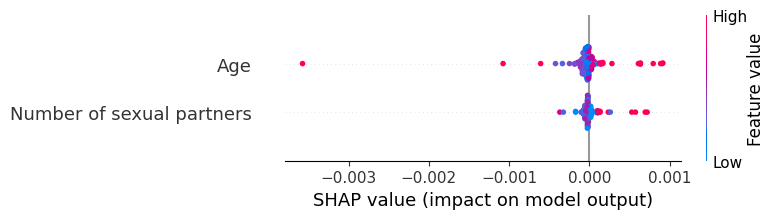

In [8]:
# Summary plot
shap.summary_plot(shap_values[:, :, 1], X_test_selected, max_display=10)